## Lecture 4 Exercises: Population Stratification

1) Preprocess input genotype data (20 pts)
a. Provide the PLINK command used to convert the VCF file to PLINK bed/bim/fam format.
b. Provide the PLINK command used to assign IDs to variants with missing variant names.
c. Report the number of variants and samples in the resulting PLINK datas


In [2]:
! cd /Users/kmlanderos/Documents/Johns_Hopkins/Spring_2026/Annotate_a_Genome/data/excercise4

# Convert VCF to binary PLINK format
! /Users/kmlanderos/Downloads/plink_mac_20250819/plink \
    --vcf ALL.2of4intersection.20100804.genotypes.vcf.gz \
    --vcf-idspace-to _ \
    --make-bed \
    --out _1KGP_initial

# Assign unique IDs (chr:pos) to variants missing names
! /Users/kmlanderos/Downloads/plink_mac_20250819/plink \
    --bfile _1KGP_initial \
    --set-missing-var-ids @:# \
    --make-bed \
    --out _1KGP_preprocessed

# Display the log to find final variant and sample counts
! cat _1KGP_preprocessed.log

PLINK v1.9.0-b.7.11 64-bit (19 Aug 2025)           cog-genomics.org/plink/1.9/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to _1KGP_initial.log.
Options in effect:
  --make-bed
  --out _1KGP_initial
  --vcf ALL.2of4intersection.20100804.genotypes.vcf.gz
  --vcf-idspace-to _

18432 MB RAM detected; reserving 9216 MB for main workspace.
--vcf: 152k variants complete.^C

PLINK v1.9.0-b.7.11 64-bit (19 Aug 2025)           cog-genomics.org/plink/1.9/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to _1KGP_preprocessed.log.
Options in effect:
  --bfile _1KGP_initial
  --make-bed
  --out _1KGP_preprocessed
  --set-missing-var-ids @:#

18432 MB RAM detected; reserving 9216 MB for main workspace.
25488488 variants loaded from .bim file.
10375501 missing IDs set.
629 people (0 males, 0 females, 629 ambiguous) loaded from .fam.
Ambiguous sex IDs written to _1KGP_preprocessed.nosex .
Using 1 thread (no multithreaded

2) QC and SNP Harmonization of 1000 Genomes Data (10 pts)
a. Provide the commands used to perform QC on the 1000 Genomes dataset, including filtering on missingness and minor allele frequency.
b. Report the number of variants and samples remaining after QC.
c. Describe how you obtained the shared SNP set between the QCed 1000 Genomes dataset and the HapMap reference panel.
d.Report the number of variants and samples remaining in:
i. the filtered 1000 Genomes dataset aPer restricted to the shared SNPs
ii the HapMap dataset after extracting the same SNP set


In [9]:
## QC on 1000 Genomes data.
# Remove variants based on missing genotype data.
! /Users/kmlanderos/Downloads/plink_mac_20250819/plink --bfile _1KGP_preprocessed --geno 0.2 --allow-no-sex --make-bed --out _1KGP_qc

# Remove individuals based on missing genotype data.
! /Users/kmlanderos/Downloads/plink_mac_20250819/plink --bfile _1KGP_qc --mind 0.02 --allow-no-sex --make-bed --out _1KGP_qc2

# Remove variants based on MAF.
! /Users/kmlanderos/Downloads/plink_mac_20250819/plink --bfile _1KGP_qc2 --maf 0.05 --allow-no-sex --make-bed --out _1KGP_qc3


PLINK v1.9.0-b.7.11 64-bit (19 Aug 2025)           cog-genomics.org/plink/1.9/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to _1KGP_qc.log.
Options in effect:
  --allow-no-sex
  --bfile _1KGP_preprocessed
  --geno 0.2
  --make-bed
  --out _1KGP_qc

18432 MB RAM detected; reserving 9216 MB for main workspace.
25488488 variants loaded from .bim file.
629 people (0 males, 0 females, 629 ambiguous) loaded from .fam.
Ambiguous sex IDs written to _1KGP_qc.nosex .
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 629 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
Total genotyping rate is 0.615305.
16481066 variants removed due to missing genotype data (--geno).
9007422 variants and 629 people pass filters and Q

In [11]:
# Extract the variants present in HapMap dataset from the 1000 genomes dataset.
! awk '{print$2}' HapMap_3_r3_qc_final.bim > HapMap_SNPs.txt
! /Users/kmlanderos/Downloads/plink_mac_20250819/plink --bfile _1KGP_qc3 --extract HapMap_SNPs.txt --make-bed --out _1KGP_qc4

# Extract the variants present in 1000 Genomes dataset from the HapMap dataset.
! awk '{print$2}' _1KGP_qc4.bim > _1KGP_qc4_SNPs.txt
! /Users/kmlanderos/Downloads/plink_mac_20250819/plink --bfile HapMap_3_r3_qc_final --extract _1KGP_qc4_SNPs.txt --recode --make-bed --out HapMap_MDS # The datasets now contain the exact same variants.

PLINK v1.9.0-b.7.11 64-bit (19 Aug 2025)           cog-genomics.org/plink/1.9/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to _1KGP_qc4.log.
Options in effect:
  --bfile _1KGP_qc3
  --extract HapMap_SNPs.txt
  --make-bed
  --out _1KGP_qc4

18432 MB RAM detected; reserving 9216 MB for main workspace.
6320784 variants loaded from .bim file.
589 people (0 males, 0 females, 589 ambiguous) loaded from .fam.
Ambiguous sex IDs written to _1KGP_qc4.nosex .
--extract: 1033828 variants remaining.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 589 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
Total genotyping rate is 0.999404.
1033828 variants and 589 people pass filters and QC.
Note: No phenotypes present.
--m

3) Harmonize Genomic Build Between HapMap and 1000 Genomes (10 pts)
a. Describe how you obtained the coordinate informatioon needed to match the 1000 Genomes SNP positions to the HapMap build.
b. Provide the command(s) used to update SNP positions in the 1000 Genomes dataset.
c. Report the number of variants and samples in the updated dataset.


In [12]:
## The datasets must have the same build. Change the build 1000 Genomes data build.
! awk '{print$2,$4}' HapMap_MDS.map > buildhapmap.txt
# buildhapmap.txt contains one SNP-id and physical position per line.

! /Users/kmlanderos/Downloads/plink_mac_20250819/plink --bfile _1KGP_qc4 --update-map buildhapmap.txt --make-bed --out _1KGP_MDS
# _1KGP_MDS and HapMap_MDS now have the same build.

PLINK v1.9.0-b.7.11 64-bit (19 Aug 2025)           cog-genomics.org/plink/1.9/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to _1KGP_MDS.log.
Options in effect:
  --bfile _1KGP_qc4
  --make-bed
  --out _1KGP_MDS
  --update-map buildhapmap.txt

18432 MB RAM detected; reserving 9216 MB for main workspace.
1033828 variants loaded from .bim file.
589 people (0 males, 0 females, 589 ambiguous) loaded from .fam.
Ambiguous sex IDs written to _1KGP_MDS.nosex .
--update-map: 1033828 values updated.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 589 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
Total genotyping rate is 0.999404.
1033828 variants and 589 people pass filters and QC.
Note: No phenotypes present.
-

4) Harmonize HapMap and 1000 Genomes Data Prior to Merging (20 pts)
a. Describe how you matched reference allele coding between the HapMap and 1000 Genomes
datasets.
b. Provide the command(s) used to identify and correct strand mismatches between datasets.
c. Describe how you identified SNPs that could not be reconciled after strand correction.
d. Explain how these problematic SNPs were removed prior to merging.
e. Report the number of variants and samples remaining in each dataset aPer harmonizaTon and filtering.


In [13]:
# Prior to merging 1000 Genomes data with the HapMap data we want to make sure that the files are mergeable, conducting 3 steps:
# 1) Make sure the reference genome is similar in the HapMap and the 1000 Genomes Project datasets.
# 2) Resolve strand issues.
# 3) Remove the SNPs which after the previous two steps still differ between datasets.

# The following steps are maybe quite technical in terms of commands, but we just compare the two data sets and make sure they correspond.

# 1) Set reference genome 
! awk '{print$2,$5}' _1KGP_MDS.bim > _1kgp_ref-list.txt
! /Users/kmlanderos/Downloads/plink_mac_20250819/plink --bfile HapMap_MDS --reference-allele _1kgp_ref-list.txt --make-bed --out HapMap-adj
# The _1KGP_MDS and the HapMap-adj have the same reference genome for all SNPs.
# This command will generate some warnings for impossible A1 allele assignment.

PLINK v1.9.0-b.7.11 64-bit (19 Aug 2025)           cog-genomics.org/plink/1.9/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to HapMap-adj.log.
Options in effect:
  --a1-allele _1kgp_ref-list.txt
  --bfile HapMap_MDS
  --make-bed
  --out HapMap-adj

18432 MB RAM detected; reserving 9216 MB for main workspace.
1033828 variants loaded from .bim file.
76 people (39 males, 37 females) loaded from .fam.
76 phenotype values loaded from .fam.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 76 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
Total genotyping rate is 0.998454.
--a1-allele: 1033828 assignments attempted, 1032957 made.
1033828 variants and 76 people pass filters and QC.
Among remaining phenotypes, 32

In [ ]:
# 2) Resolve strand issues.
# Check for potential strand issues.
! awk '{print$2,$5,$6}' _1KGP_MDS.bim > _1KGP_MDS7_tmp
! awk '{print$2,$5,$6}' HapMap-adj.bim > HapMap-adj_tmp
! sort _1KGP_MDS7_tmp HapMap-adj_tmp |uniq -u > all_differences.txt
# 1752 differences between the files, some of these might be due to strand issues.

## Flip SNPs for resolving strand issues.
# Print SNP-identifier and remove duplicates.
! awk '{print$1}' all_differences.txt | sort -u > flip_list.txt
# Generates a file of 876 SNPs. These are the non-corresponding SNPs between the two files. 
# Flip the 876 non-corresponding SNPs. 
! /Users/kmlanderos/Downloads/plink_mac_20250819/plink --bfile HapMap-adj --flip flip_list.txt --reference-allele _1kgp_ref-list.txt --make-bed --out corrected_hapmap

# Check for SNPs which are still problematic after they have been flipped.
! awk '{print$2,$5,$6}' corrected_hapmap.bim > corrected_hapmap_tmp
! sort _1KGP_MDS7_tmp corrected_hapmap_tmp |uniq -u  > uncorresponding_SNPs.txt


PLINK v1.9.0-b.7.11 64-bit (19 Aug 2025)           cog-genomics.org/plink/1.9/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to corrected_hapmap.log.
Options in effect:
  --a1-allele _1kgp_ref-list.txt
  --bfile HapMap-adj
  --flip flip_list.txt
  --make-bed
  --out corrected_hapmap

18432 MB RAM detected; reserving 9216 MB for main workspace.
1033828 variants loaded from .bim file.
76 people (39 males, 37 females) loaded from .fam.
76 phenotype values loaded from .fam.
--flip: 876 SNPs flipped.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 76 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
Total genotyping rate is 0.998454.
--a1-allele: 1033828 assignments attempted, 1033821 made.
1033828 variants and 

In [16]:
# 3) Remove problematic SNPs from HapMap and 1000 Genomes.
! awk '{print$1}' uncorresponding_SNPs.txt | sort -u > SNPs_for_exlusion.txt
# The command above generates a list of the 56 SNPs which caused the 84 differences between the HapMap and the 1000 Genomes data sets after flipping and setting of the reference genome.

# Remove the 56 problematic SNPs from both datasets.
! /Users/kmlanderos/Downloads/plink_mac_20250819/plink --bfile corrected_hapmap --exclude SNPs_for_exlusion.txt --make-bed --out HapMap_MDS2
! /Users/kmlanderos/Downloads/plink_mac_20250819/plink --bfile _1KGP_MDS --exclude SNPs_for_exlusion.txt --make-bed --out _1KGP_MDS2

PLINK v1.9.0-b.7.11 64-bit (19 Aug 2025)           cog-genomics.org/plink/1.9/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to HapMap_MDS2.log.
Options in effect:
  --bfile corrected_hapmap
  --exclude SNPs_for_exlusion.txt
  --make-bed
  --out HapMap_MDS2

18432 MB RAM detected; reserving 9216 MB for main workspace.
1033828 variants loaded from .bim file.
76 people (39 males, 37 females) loaded from .fam.
76 phenotype values loaded from .fam.
--exclude: 1033772 variants remaining.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 76 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
Total genotyping rate is 0.998454.
1033772 variants and 76 people pass filters and QC.
Among remaining phenotypes, 32 are cases

5) Merge HapMap and 1000 Genomes Data (10 pts)
a. Provide the command used to merge the harmonized HapMap and 1000 Genomes datasets.
b. Report the number of variants and samples in the merged dataset.
c. Briefly note whether the merge was successful.


In [17]:
# Merge HapMap with 1000 Genomes Data.
! /Users/kmlanderos/Downloads/plink_mac_20250819/plink --bfile HapMap_MDS2 --bmerge _1KGP_MDS2.bed _1KGP_MDS2.bim _1KGP_MDS2.fam --allow-no-sex --make-bed --out MDS_merge2


PLINK v1.9.0-b.7.11 64-bit (19 Aug 2025)           cog-genomics.org/plink/1.9/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to MDS_merge2.log.
Options in effect:
  --allow-no-sex
  --bfile HapMap_MDS2
  --bmerge _1KGP_MDS2.bed _1KGP_MDS2.bim _1KGP_MDS2.fam
  --make-bed
  --out MDS_merge2

18432 MB RAM detected; reserving 9216 MB for main workspace.
76 people loaded from HapMap_MDS2.fam.
589 people to be merged from _1KGP_MDS2.fam.
Of these, 589 are new, while 0 are present in the base dataset.
1033772 markers loaded from HapMap_MDS2.bim.
1033772 markers to be merged from _1KGP_MDS2.bim.
Of these, 0 are new, while 1033772 are present in the base dataset.
Performing single-pass merge (665 people, 1033772 variants).
Merged fileset written to MDS_merge2-merge.bed + MDS_merge2-merge.bim +
MDS_merge2-merge.fam .
1033772 variants loaded from .bim file.
665 people (39 males, 37 females, 589 ambiguous) loaded from .fam.
Ambiguous sex IDs written to MDS_

6) Perform MDS Analysis and Visualize Population Structure (40 pts)
a. Provide the command(s) used to compute geneTc distances and run MDS on the merged
HapMap/1000 Genomes dataset.
b. Report the number of variants and samples included in the MDS analysis.
c. Describe how you prepared the MDS results for plotting, including any sample annotation,
grouping, or subsetting steps.
d. Generate and include the final MDS plot.
e. Briefly interpret the plot by identifying the major reference populaTon clusters and the inferred
ancestry of the study sample(s).


In [ ]:
## MDS on HapMap-CEU data anchored by 1000 Genomes data.
# Using a set of pruned SNPs
! /Users/kmlanderos/Downloads/plink_mac_20250819/plink --bfile MDS_merge2 --extract indepSNP.prune.in --genome --out MDS_merge2
! /Users/kmlanderos/Downloads/plink_mac_20250819/plink --bfile MDS_merge2 --read-genome MDS_merge2.genome --cluster --mds-plot 10 --out MDS_merge2

In [3]:
# Convert population codes into superpopulation codes (i.e., AFR,AMR,ASN, and EUR).
! awk '{print$1,$1,$2}' 20100804.ALL.panel > race_1kG.txt
! sed 's/JPT/ASN/g' race_1kG.txt>race_1kG2.txt
! sed 's/ASW/AFR/g' race_1kG2.txt>race_1kG3.txt
! sed 's/CEU/EUR/g' race_1kG3.txt>race_1kG4.txt
! sed 's/CHB/ASN/g' race_1kG4.txt>race_1kG5.txt
! sed 's/CHD/ASN/g' race_1kG5.txt>race_1kG6.txt
! sed 's/YRI/AFR/g' race_1kG6.txt>race_1kG7.txt
! sed 's/LWK/AFR/g' race_1kG7.txt>race_1kG8.txt
! sed 's/TSI/EUR/g' race_1kG8.txt>race_1kG9.txt
! sed 's/MXL/AMR/g' race_1kG9.txt>race_1kG10.txt
! sed 's/GBR/EUR/g' race_1kG10.txt>race_1kG11.txt
! sed 's/FIN/EUR/g' race_1kG11.txt>race_1kG12.txt
! sed 's/CHS/ASN/g' race_1kG12.txt>race_1kG13.txt
! sed 's/PUR/AMR/g' race_1kG13.txt>race_1kG14.txt

# Create a racefile of your own data.
! awk '{print$1,$2,"HapMap"}' HapMap_MDS.fam>racefile_HapMap.txt

# Concatenate racefiles.
! cat race_1kG14.txt racefile_HapMap.txt | awk 'BEGIN{print "FID IID race"} {print}' > racefile.txt

    FID      IID  SOL        C1        C2        C3        C4        C5  \
0  1328  NA06984    0 -0.055998  0.048316  0.003867 -0.004883  0.028714   
1  1328  NA06989    0 -0.055753  0.047621  0.010257 -0.010620  0.017534   
2  1330  NA12340    0 -0.056051  0.048922  0.007427 -0.008675  0.007132   
3  1330  NA12343    0 -0.056294  0.045067  0.001847 -0.001367  0.008056   
4  1334  NA12146    0 -0.056531  0.050427  0.005459 -0.005595  0.010292   

         C6        C7        C8        C9       C10    race  
0 -0.002161  0.022857 -0.012823  0.037470 -0.013674  HapMap  
1 -0.003278  0.015117  0.091232 -0.005905  0.005990  HapMap  
2 -0.020917 -0.005409 -0.006834  0.035245 -0.008034  HapMap  
3  0.000209  0.001316  0.000650 -0.000872  0.001736  HapMap  
4  0.002002  0.005775  0.005062 -0.002052 -0.009414  HapMap  


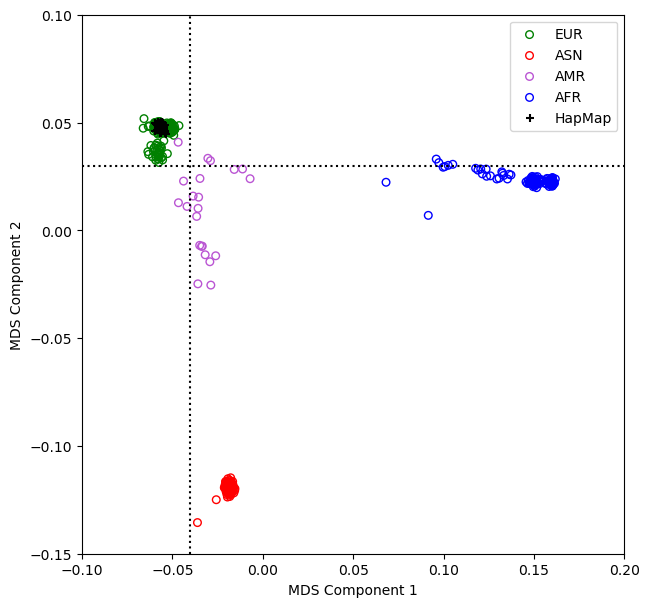

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Read the datasets (using whitespace delimiter since these are PLINK/text files)
data = pd.read_csv("MDS_merge2.mds", sep=r'\s+', header=0)
race = pd.read_csv("racefile.txt", sep=r'\s+', header=0)

# 2. Merge the datasets by FID and IID
datafile = pd.merge(data, race, on=["FID", "IID"])
print(datafile.head())

# 3. Initialize the plot (7x7 inches to match your pdf width/height)
plt.figure(figsize=(7, 7))

# 4. Define plotting aesthetics mapped to your R code
# R pch=1 is an empty circle, pch=3 is a plus sign (+)
# R color 470 is approximately "mediumorchid" or purple
groups = {
    "EUR": {"color": "green", "marker": "o", "fill": "none"},
    "ASN": {"color": "red", "marker": "o", "fill": "none"},
    "AMR": {"color": "mediumorchid", "marker": "o", "fill": "none"}, 
    "AFR": {"color": "blue", "marker": "o", "fill": "none"},
    "HapMap": {"color": "black", "marker": "+", "fill": "black"}
}

# 5. Plot each group
for race_label, props in groups.items():
    # Subset the data for the current race
    subset = datafile[datafile['race'] == race_label]
    
    if not subset.empty:
        # In R, you used columns 4 and 5 (1-based index). In Python, these are indices 3 and 4.
        # If your columns are explicitly named 'C1' and 'C2', it is safer to use subset['C1'], subset['C2']
        x = subset.iloc[:, 3] 
        y = subset.iloc[:, 4]
        
        if props['marker'] == 'o':
            # Empty circles
            plt.scatter(x, y, edgecolors=props['color'], facecolors='none', 
                        marker=props['marker'], s=30, label=race_label)
        else:
            # Plus signs
            plt.scatter(x, y, color=props['color'], 
                        marker=props['marker'], s=40, label=race_label)

# 6. Apply axis limits and labels
plt.xlim(-0.1, 0.2)
plt.ylim(-0.15, 0.1)
plt.xlabel("MDS Component 1")
plt.ylabel("MDS Component 2")

# 7. Add threshold lines (lty=3 in R is a dotted line in Python)
plt.axvline(x=-0.040, linestyle=':', color='black')
plt.axhline(y=0.030, linestyle=':', color='black')

# 8. Add legend
plt.legend(loc="upper right", frameon=True)

# 9. Save as PDF and display
plt.savefig("MDS.pdf", format='pdf', bbox_inches='tight')
plt.show()

7) Generate MDS-Based Covariates for Downstream Analysis (10 pts)
a. Describe how you generated the covariate file from the MDS results.
b. Report the MDS components included in the covariate file.
c. Briefly explain why these covariates are included in downstream analyses.


In [24]:
## Exclude ethnic outliers.
# Select individuals in HapMap data below cut-off thresholds. To exclude ethnic outliers, the thresholds need to be set around the cluster of population of interest.
! awk '{ if ($4 <-0.04 && $5 >0.03) print $1,$2 }' MDS_merge2.mds > EUR_MDS_merge2

# Extract these individuals in HapMap data.
! /Users/kmlanderos/Downloads/plink_mac_20250819/plink --bfile HapMap_3_r3_qc_final --keep EUR_MDS_merge2 --make-bed --out HapMap_3_r3_pop_strat
# Note, since our HapMap data did include any ethnic outliers, no individuls were removed at this step. However, if our data would have included individuals outside of the thresholds we set, then these individuals would have been removed.

## Create covariates based on MDS.
# Perform an MDS ONLY on HapMap data without ethnic outliers. The values of the 10 MDS dimensions are subsequently used as covariates in the association analysis in the third tutorial.
! /Users/kmlanderos/Downloads/plink_mac_20250819/plink --bfile HapMap_3_r3_pop_strat --extract indepSNP.prune.in --genome --out HapMap_3_r3_pop_strat
! /Users/kmlanderos/Downloads/plink_mac_20250819/plink --bfile HapMap_3_r3_pop_strat --read-genome HapMap_3_r3_pop_strat.genome --cluster --mds-plot 10 --out HapMap_3_r3_pop_strat_mds

# Change the format of the .mds file into a plink covariate file.
! awk '{print$1, $2, $4, $5, $6, $7, $8, $9, $10, $11, $12, $13}' HapMap_3_r3_pop_strat_mds.mds > covar_mds.txt


PLINK v1.9.0-b.7.11 64-bit (19 Aug 2025)           cog-genomics.org/plink/1.9/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to HapMap_3_r3_pop_strat.log.
Options in effect:
  --bfile HapMap_3_r3_qc_final
  --keep EUR_MDS_merge2
  --make-bed
  --out HapMap_3_r3_pop_strat

18432 MB RAM detected; reserving 9216 MB for main workspace.
1073788 variants loaded from .bim file.
76 people (39 males, 37 females) loaded from .fam.
76 phenotype values loaded from .fam.
--keep: 76 people remaining.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 76 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
Total genotyping rate is 0.998455.
1073788 variants and 76 people pass filters and QC.
Among remaining phenotypes, 32 are c